In [2]:
from neuralop.models.fno import FNO
import torch
from torchinfo import summary
import matplotlib.pyplot as plt

/Users/ntt/anaconda3/envs/torch/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [3]:
fno_model = FNO(n_modes=(8, 32, 16), in_channels=6, out_channels=4, n_layers=4, hidden_channels=64)
summary(fno_model, input_size=(1, 6, 16, 64, 32))

Layer (type:depth-idx)                   Output Shape              Param #
FNO                                      [1, 4, 16, 64, 32]        --
├─GridEmbeddingND: 1-1                   [1, 9, 16, 64, 32]        --
├─ChannelMLP: 1-2                        [1, 64, 16, 64, 32]       --
│    └─ModuleList: 2-1                   --                        --
│    │    └─Conv1d: 3-1                  [1, 128, 32768]           1,280
│    │    └─Conv1d: 3-2                  [1, 64, 32768]            8,256
├─FNOBlocks: 1-3                         [1, 64, 16, 64, 32]       28,336,800
│    └─ModuleList: 2-14                  --                        (recursive)
│    │    └─Flattened1dConv: 3-3         [1, 64, 16, 64, 32]       4,096
│    └─ModuleList: 2-15                  --                        (recursive)
│    │    └─SoftGating: 3-4              [1, 64, 16, 64, 32]       64
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─SpectralConv: 3-5            

In [18]:
from LOGLO_FNO_v2 import LOGLO_FNO

loglo_model = LOGLO_FNO(in_dim=8, out_dim=4, lifting_dim=256, projection_dim=256, hidden_dim=64,
                        n_blocks=5, action_channels=6)

loglo_model.load_state_dict(torch.load("checkpoints/42/hetero_loglo_final.pth", map_location=torch.device('cpu'), weights_only=False)["ema_model"])

<All keys matched successfully>

In [19]:
out_fields, energy_bhp = loglo_model(torch.randn(1, 8, 16, 64, 32), torch.randn(1, 6, 16, 64, 32))

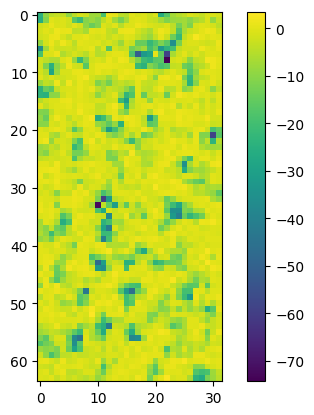

In [22]:
plt.imshow(out_fields[0, 0, 10, :, :].detach().numpy())
plt.colorbar()
plt.show()